# Rich-circuit scaling sweep

LR sweep, then main scaling runs on a rich circuit (all wires tapped at uniform depths, all outputs trained, online data). Same recipe as `colab_sweep.ipynb`. Runs are idempotent: rerun any cell to resume.

In [2]:
import os
import sys

if "google.colab" in sys.modules:
    %pip -q install -U "jax[cuda12]" optax
    if not os.path.exists("/content/circscale"):
        !git clone https://github.com/amdson/circscale.git /content/circscale
    %cd /content/circscale
    !git pull
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs("/content/drive/MyDrive/circscale_runs", exist_ok=True)
    if not os.path.islink("runs"):
        os.symlink("/content/drive/MyDrive/circscale_runs", "runs")

import jax
print(jax.devices())

/content/circscale
Already up to date.
Mounted at /content/drive
[CudaDevice(id=0)]


In [12]:
import json
from pathlib import Path

import numpy as np

from train import RunConfig, run

N_WIRES, CIRC_DEPTH, CIRCUIT_SEED = 200, 15, 0
GRID = [(32, 2), (48, 2), (64, 3), (96, 3), (128, 4),
        (180, 5), (256, 6), (360, 7), (512, 8)]
LR_GRID = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
TUNE_STEPS, FULL_STEPS, BATCH = 5_000, 100_000, 256
OUT_DIR = f"runs/rich_c{N_WIRES}x{CIRC_DEPTH}"
LR_TABLE = Path(OUT_DIR) / "lr_table.json"


def cfg(width, depth, lr, steps, out_dir, seed=0):
    return RunConfig(width=width, mlp_depth=depth, lr=lr, steps=steps, batch=BATCH,
                     n_wires=N_WIRES, circ_depth=CIRC_DEPTH,
                     circuit_seed=CIRCUIT_SEED, model_seed=seed, out_dir=out_dir)

## LR sweep

In [6]:
table = {}
for w, d in GRID:
    losses = {}
    for lr in LR_GRID:
        c = cfg(w, d, lr, TUNE_STEPS, f"{OUT_DIR}/tune")
        run(c)
        losses[lr] = float(np.load(c.npz_path)["per_out_loss"][-1].mean())
    table[f"w{w}d{d}"] = best = min(losses, key=losses.get)
    edge = "  <- grid edge" if best in (LR_GRID[0], LR_GRID[-1]) else ""
    print(f"w{w}d{d}: best lr {best:g}{edge}")
LR_TABLE.write_text(json.dumps(table, indent=2))

[skip] w32_d2_b256_lr0.0001_s5000_c100x10_cs0_ms0 (done)
[skip] w32_d2_b256_lr0.0003_s5000_c100x10_cs0_ms0 (done)
[skip] w32_d2_b256_lr0.001_s5000_c100x10_cs0_ms0 (done)
[skip] w32_d2_b256_lr0.003_s5000_c100x10_cs0_ms0 (done)
[skip] w32_d2_b256_lr0.01_s5000_c100x10_cs0_ms0 (done)
w32d2: best lr 0.01  <- grid edge
[skip] w48_d2_b256_lr0.0001_s5000_c100x10_cs0_ms0 (done)
[skip] w48_d2_b256_lr0.0003_s5000_c100x10_cs0_ms0 (done)
[skip] w48_d2_b256_lr0.001_s5000_c100x10_cs0_ms0 (done)
[skip] w48_d2_b256_lr0.003_s5000_c100x10_cs0_ms0 (done)
[skip] w48_d2_b256_lr0.01_s5000_c100x10_cs0_ms0 (done)
w48d2: best lr 0.01  <- grid edge
[skip] w64_d3_b256_lr0.0001_s5000_c100x10_cs0_ms0 (done)
[skip] w64_d3_b256_lr0.0003_s5000_c100x10_cs0_ms0 (done)
[skip] w64_d3_b256_lr0.001_s5000_c100x10_cs0_ms0 (done)
[skip] w64_d3_b256_lr0.003_s5000_c100x10_cs0_ms0 (done)
[skip] w64_d3_b256_lr0.01_s5000_c100x10_cs0_ms0 (done)
w64d3: best lr 0.01  <- grid edge
[skip] w96_d3_b256_lr0.0001_s5000_c100x10_cs0_ms0 (done

w512_d8_b256_lr0.0001_s5000_c100x10_cs0_ms0:   0%|          | 0/5000 [00:00<?, ?it/s]

[done] w512_d8_b256_lr0.0001_s5000_c100x10_cs0_ms0: eval loss 0.5343, acc 0.6439, 1.3 min


w512_d8_b256_lr0.0003_s5000_c100x10_cs0_ms0:   0%|          | 0/5000 [00:00<?, ?it/s]

[done] w512_d8_b256_lr0.0003_s5000_c100x10_cs0_ms0: eval loss 0.4921, acc 0.6747, 1.3 min


...

w512_d8_b256_lr0.003_s5000_c100x10_cs0_ms0:   0%|          | 0/5000 [00:00<?, ?it/s]

[done] w512_d8_b256_lr0.003_s5000_c100x10_cs0_ms0: eval loss 0.4965, acc 0.6719, 1.3 min


w512_d8_b256_lr0.01_s5000_c100x10_cs0_ms0:   0%|          | 0/5000 [00:00<?, ?it/s]

[done] w512_d8_b256_lr0.01_s5000_c100x10_cs0_ms0: eval loss 0.5136, acc 0.6580, 1.3 min
w512d8: best lr 0.001


166

In [15]:
table

{'w32d2': 0.01,
 'w48d2': 0.01,
 'w64d3': 0.01,
 'w96d3': 0.003,
 'w128d4': 0.003,
 'w180d5': 0.003,
 'w256d6': 0.003,
 'w360d7': 0.001,
 'w512d8': 0.001}

## Main runs

In [ ]:
# table = json.loads(LR_TABLE.read_text())
for w, d in GRID:
    run(cfg(w, d, table[f"w{w}d{d}"], FULL_STEPS, OUT_DIR))

w32_d2_b256_lr0.01_s100000_c200x15_cs0_ms0:   0%|          | 0/100000 [00:00<?, ?it/s]

## Results

/tmp/ipykernel_1917/872612606.py:22: OptimizeWarning: Covariance of the parameters could not be estimated
  (lE, lA, a), _ = curve_fit(f, np.log(N), np.log(L), p0=(np.log(0.9 * L.min()), 1.0, 0.3),


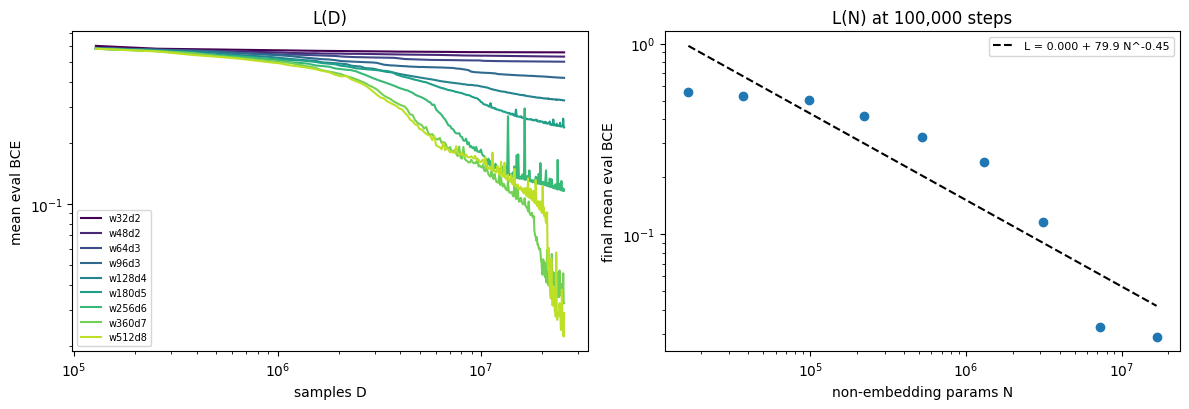

In [11]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from train import load_run

N, L = [], []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for (w, d), col in zip(GRID, plt.cm.viridis(np.linspace(0, 0.9, len(GRID)))):
    c = cfg(w, d, table[f"w{w}d{d}"], FULL_STEPS, OUT_DIR)
    if not c.npz_path.exists():
        continue
    _, r = load_run(c.npz_path)
    m = r["eval_steps"] > 0
    ax1.plot(r["eval_steps"][m] * BATCH, r["per_out_loss"][m].mean(axis=1), color=col,
             label=f"w{w}d{d}")
    N.append(d * (w + 8 * w * w) + w)  # non-embedding params
    L.append(r["per_out_loss"][-1].mean())
N, L = np.array(N), np.array(L)

# L(N) = E + A * N^-alpha, fit in log space
f = lambda lN, lE, lA, a: np.log(np.exp(lE) + np.exp(lA - a * lN))
(lE, lA, a), _ = curve_fit(f, np.log(N), np.log(L), p0=(np.log(0.9 * L.min()), 1.0, 0.3),
                           maxfev=20000)
xs = np.logspace(np.log10(N.min()), np.log10(N.max()), 100)
ax2.plot(N, L, "o")
ax2.plot(xs, np.exp(lE) + np.exp(lA) * xs ** -a, "k--",
         label=f"L = {np.exp(lE):.3f} + {np.exp(lA):.3g} N^-{a:.2f}")
ax1.set(xscale="log", yscale="log", xlabel="samples D", ylabel="mean eval BCE", title="L(D)")
ax2.set(xscale="log", yscale="log", xlabel="non-embedding params N",
        ylabel="final mean eval BCE", title=f"L(N) at {FULL_STEPS:,} steps")
ax1.legend(fontsize=7); ax2.legend(fontsize=8)
plt.tight_layout()